# Dynamic Graph Edge Weight Analysis

This notebook analyzes the edge weights (distances or similarities) of the dynamic graphs constructed using the top-k percentile approach. 

**Goal:** Understand the distribution of edge weights across all graphs in the time sequence to design an *adaptive threshold*. This threshold will act as a secondary filter to remove edges that were included by the top-k percentile but are nonetheless "too far" (for distance) or "too dissimilar" (for similarity) due to the changing scale of the graph over time.

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)

## 1. Configuration
Select the parameters corresponding to the dynamic graphs you want to analyze.

In [ ]:
BASE_DIR = r"c:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\DynamicSimilarities\GraphAnalysis\DynamicGraphPkls"

# --- Configuration ---
ITEM_ID = 907969
METRIC = "spearman"  # e.g., 'cid', 'spearman', 'euclidean'
METRIC_TYPE = "similarity"  # 'distance' (lower is better) or 'similarity' (higher is better)
WINDOW_SIZE = 15
STEP_SIZE = 1
PREFIX = "" # e.g., "", "star_", "2nddegree_", "2nddegree_star_"
PERCENTILE = 0.5  # e.g., 0.5, 1, 2

# Resolve directory and file paths
dir_label = f"pct{PERCENTILE}"
plot_dir_name = f"{PREFIX}{dir_label}" if PREFIX else dir_label

target_dir = os.path.join(BASE_DIR, str(ITEM_ID), METRIC, str(WINDOW_SIZE), str(STEP_SIZE), plot_dir_name)
pkl_filename = f"{PREFIX}dynamic_graphs_{METRIC}_Window{WINDOW_SIZE}_Step{STEP_SIZE}_{dir_label}.pkl"

if METRIC_TYPE == "distance":
    csv_filename = pkl_filename.replace('.pkl', '_worst_distances.csv')
else:
    csv_filename = pkl_filename.replace('.pkl', '_worst_similarities.csv')

pkl_path = os.path.join(target_dir, pkl_filename)
csv_path = os.path.join(target_dir, csv_filename)

print(f"Target Pickle Path: {pkl_path}")
print(f"Target CSV Path: {csv_path}")

if not os.path.exists(pkl_path):
    print("\nWARNING: Pickle file does not exist. Check your configuration.")

Target Pickle Path: c:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\DynamicSimilarities\GraphAnalysis\DynamicGraphPkls\26008\spearman\15\1\pct0.5\dynamic_graphs_spearman_Window15_Step1_pct0.5.pkl
Target CSV Path: c:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\DynamicSimilarities\GraphAnalysis\DynamicGraphPkls\26008\spearman\15\1\pct0.5\dynamic_graphs_spearman_Window15_Step1_pct0.5_worst_similarities.csv


## 2. Load Data

In [3]:
def load_graph_data(pkl_path, csv_path):
    # Load graphs
    with open(pkl_path, 'rb') as f:
        graphs = pickle.load(f)
    
    # Extract all weights
    all_weights = []
    graph_stats = []
    
    for i, g in enumerate(graphs):
        weights = [data.get('weight', 0) for u, v, data in g.edges(data=True)]
        all_weights.extend(weights)
        
        if len(weights) > 0:
            stats = {
                'window_idx': i,
                'window_start': g.graph.get('start_date'),
                'num_nodes': g.number_of_nodes(),
                'num_edges': g.number_of_edges(),
                'mean': np.mean(weights),
                'median': np.median(weights),
                'std': np.std(weights),
                'min': np.min(weights),
                'max': np.max(weights),
            }
        else:
             stats = {
                'window_idx': i,
                'window_start': g.graph.get('start_date'),
                'num_nodes': g.number_of_nodes(), 'num_edges': 0,
                'mean': np.nan, 'median': np.nan, 'std': np.nan, 'min': np.nan, 'max': np.nan
            }
        graph_stats.append(stats)
    
    df_stats = pd.DataFrame(graph_stats)
    if 'window_start' in df_stats.columns:
        df_stats['window_start'] = pd.to_datetime(df_stats['window_start'])
    
    # Load Worst CSV if exists
    df_worst = None
    if os.path.exists(csv_path):
        df_worst = pd.read_csv(csv_path)
    
    return graphs, all_weights, df_stats, df_worst

graphs, all_weights, df_stats, df_worst = load_graph_data(pkl_path, csv_path)
print(f"Loaded {len(graphs)} graphs.")
print(f"Total edges across all time steps: {len(all_weights)}")
df_stats.head()

Loaded 595 graphs.
Total edges across all time steps: 6861


,window_idx,window_start,num_nodes,num_edges,mean,median,std,min,max
0,0,2021-01-23,8,8,0.889286,0.882143,0.021053,0.871429,0.942857
1,1,2021-01-24,8,9,0.899206,0.892857,0.015131,0.885714,0.932143
2,2,2021-01-25,8,12,0.910417,0.914286,0.014973,0.885714,0.932143
3,3,2021-01-26,8,12,0.926488,0.921429,0.016589,0.910714,0.967857
4,4,2021-01-27,8,11,0.911039,0.914286,0.014160,0.882143,0.939286


In [4]:
print(graphs[0].graph)
print(df_worst.head() if df_worst is not None else "No df_worst")

{'start_date': '2021-01-23', 'end_date': '2021-02-06'}
No df_worst


## 3. Analysis of Worst Edges Over Time
Here we observe the "worst" distance or similarity captured in each time window. A high variance here means the top-k percentile approach is capturing very different qualities of edges depending on the window.

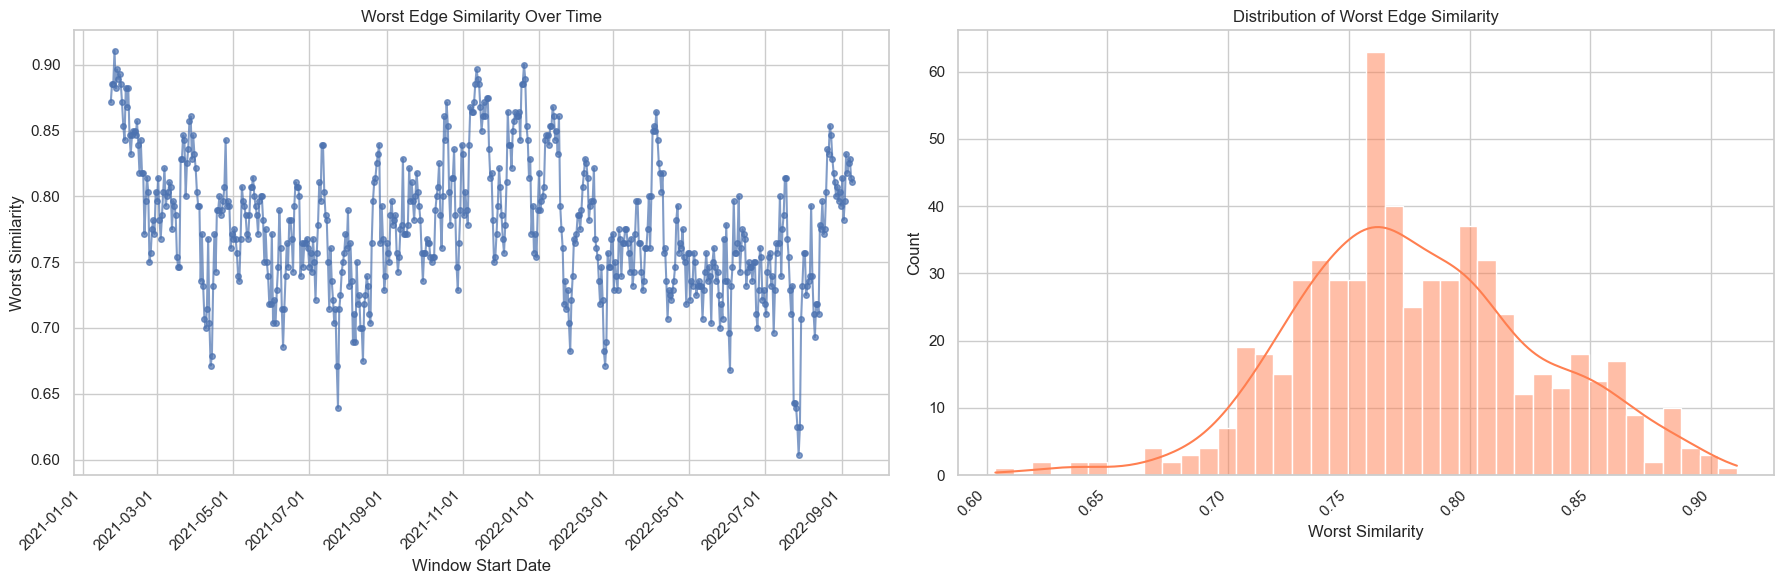

In [5]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

col_name = 'worst_distance' if METRIC_TYPE == 'distance' else 'worst_similarity'
worst_series = df_worst[col_name] if df_worst is not None else (df_stats['max'] if METRIC_TYPE == 'distance' else df_stats['min'])

# Line plot over time
ax[0].plot(df_stats['window_start'], worst_series, marker='o', markersize=4, linestyle='-', alpha=0.7)
ax[0].set_title(f"Worst Edge {METRIC_TYPE.capitalize()} Over Time")
ax[0].set_xlabel("Window Start Date")
ax[0].set_ylabel(f"Worst {METRIC_TYPE.capitalize()}")
ax[0].xaxis.set_major_locator(mdates.AutoDateLocator())
ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate(rotation=45)

# Histogram of worst distances
sns.histplot(worst_series.dropna(), bins=40, kde=True, ax=ax[1], color='coral')
ax[1].set_title(f"Distribution of Worst Edge {METRIC_TYPE.capitalize()}")
ax[1].set_xlabel(f"Worst {METRIC_TYPE.capitalize()}")

plt.tight_layout()
plt.show()

## 4. Overall Edge Weight Distribution
Let's look at the overall distribution of all edge weights to understand the global scale.

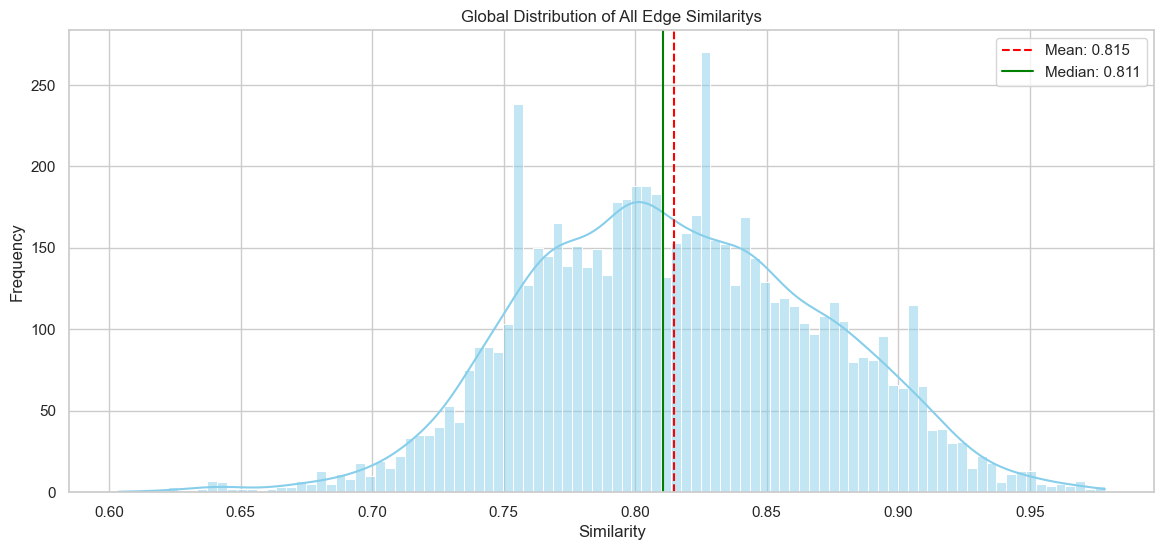

Global Percentiles:
P10: 0.7464
P25: 0.7750
P50: 0.8107
P75: 0.8536
P90: 0.8893
P95: 0.9071
P99: 0.9393


In [6]:
plt.figure(figsize=(14, 6))
sns.histplot(all_weights, bins=100, kde=True, color='skyblue')
plt.title(f"Global Distribution of All Edge {METRIC_TYPE.capitalize()}s")
plt.xlabel(METRIC_TYPE.capitalize())
plt.ylabel("Frequency")
plt.axvline(np.mean(all_weights), color='red', linestyle='--', label=f'Mean: {np.mean(all_weights):.3f}')
plt.axvline(np.median(all_weights), color='green', linestyle='-', label=f'Median: {np.median(all_weights):.3f}')
plt.legend()
plt.show()

percentiles = [10, 25, 50, 75, 90, 95, 99]
print("Global Percentiles:")
for p in percentiles:
    print(f"P{p}: {np.percentile(all_weights, p):.4f}")

## 5. Adaptive Thresholding
We can calculate a threshold based on the distribution statistics to filter out edges that are considered outliers.

**Distance Metric**: We want to remove edges where `weight > threshold`.
**Similarity Metric**: We want to remove edges where `weight < threshold`.

### Strategies:
1. **Global MAD (Median Absolute Deviation)**: Robust to outliers. `Threshold = Median +/- k * MAD`
2. **Global Mean/Std**: `Threshold = Mean +/- k * Std`
3. **Global Percentile**: Strictly cut off the worst X% of all constructed edges.

In [7]:
def calculate_thresholds(weights, metric_type, k_std=2.0, p_cutoff=95):
    mean_w = np.mean(weights)
    std_w = np.std(weights)
    median_w = np.median(weights)
    # Approximate MAD
    mad_w = np.median(np.abs(weights - median_w))
    
    thresholds = {}
    if metric_type == "distance":
        # For distances, worst is high. So we cutoff everything ABOVE threshold
        thresholds['Mean + k*Std'] = mean_w + k_std * std_w
        thresholds['Median + k*MAD'] = median_w + (k_std * 1.4826) * mad_w # 1.4826 scales MAD to match std for normal dist
        thresholds[f'Percentile {p_cutoff}'] = np.percentile(weights, p_cutoff)
    else:
        # For similarities, worst is low. So we cutoff everything BELOW threshold
        thresholds['Mean - k*Std'] = mean_w - k_std * std_w
        thresholds['Median - k*MAD'] = median_w - (k_std * 1.4826) * mad_w
        thresholds[f'Percentile {100-p_cutoff}'] = np.percentile(weights, 100 - p_cutoff)
        
    return thresholds

candidate_thresholds = calculate_thresholds(all_weights, METRIC_TYPE, k_std=1.5, p_cutoff=90)

print("Candidate Adaptive Thresholds:")
for name, val in candidate_thresholds.items():
    print(f"- {name}: {val:.4f}")

Candidate Adaptive Thresholds:
- Mean - k*Std: 0.7311
- Median - k*MAD: 0.7233
- Percentile 10: 0.7464


### Visualize Thresholds

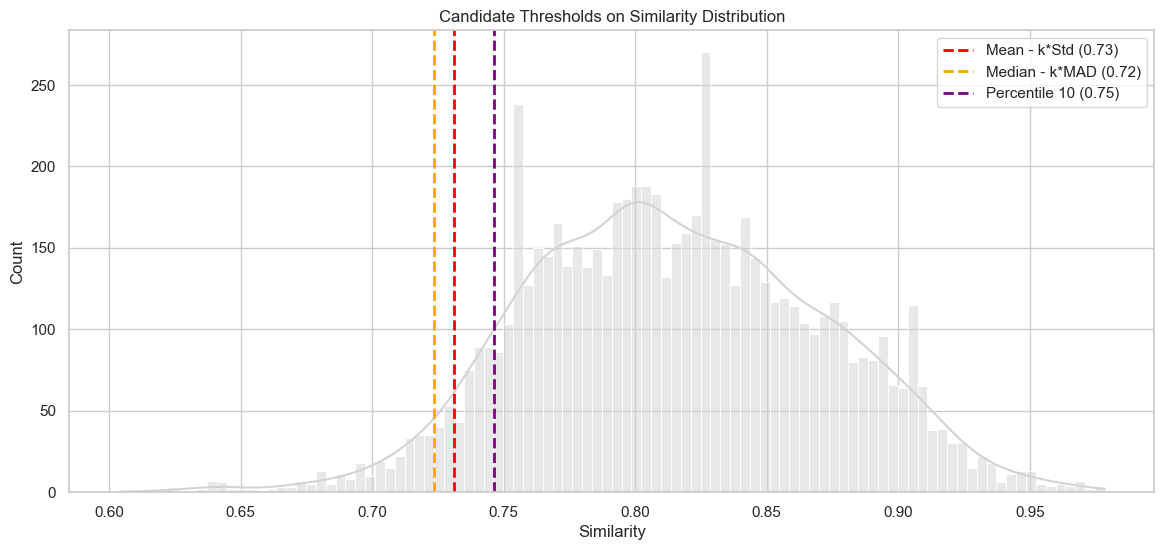

In [8]:
plt.figure(figsize=(14, 6))
sns.histplot(all_weights, bins=100, kde=True, color='lightgray')
plt.title(f"Candidate Thresholds on {METRIC_TYPE.capitalize()} Distribution")
plt.xlabel(METRIC_TYPE.capitalize())

colors = ['red', 'orange', 'purple']
for (name, val), color in zip(candidate_thresholds.items(), colors):
    plt.axvline(val, color=color, linestyle='--', linewidth=2, label=f"{name} ({val:.2f})")

plt.legend()
plt.show()

## 6. Apply Adaptive Threshold
Choose a threshold and apply it to the graph sequence to see how many edges are retained.

In [9]:
# SELECT YOUR THRESHOLD HERE
CHOSEN_THRESHOLD_KEY = list(candidate_thresholds.keys())[1] # Using Median +/- k*MAD by default
threshold_value = candidate_thresholds[CHOSEN_THRESHOLD_KEY]

print(f"Applying threshold: {CHOSEN_THRESHOLD_KEY} = {threshold_value:.4f}")

filtered_graphs = []
total_edges_before = 0
total_edges_after = 0

for g in graphs:
    g_filtered = g.copy()
    total_edges_before += g.number_of_edges()
    
    if METRIC_TYPE == "distance":
        edges_to_remove = [(u, v) for u, v, data in g.edges(data=True) if data.get('weight', 0) > threshold_value]
    else:
        edges_to_remove = [(u, v) for u, v, data in g.edges(data=True) if data.get('weight', 0) < threshold_value]
        
    g_filtered.remove_edges_from(edges_to_remove)
    filtered_graphs.append(g_filtered)
    total_edges_after += g_filtered.number_of_edges()

print(f"Total edges before filtering: {total_edges_before}")
print(f"Total edges after filtering:  {total_edges_after}")
print(f"Edges removed: {total_edges_before - total_edges_after} ({((total_edges_before - total_edges_after)/total_edges_before)*100:.2f}%)")

Applying threshold: Median - k*MAD = 0.7233
Total edges before filtering: 6861
Total edges after filtering:  6588
Edges removed: 273 (3.98%)


## 7. Compare Graph Statistics Before and After
We can see how the median number of edges per graph has changed.

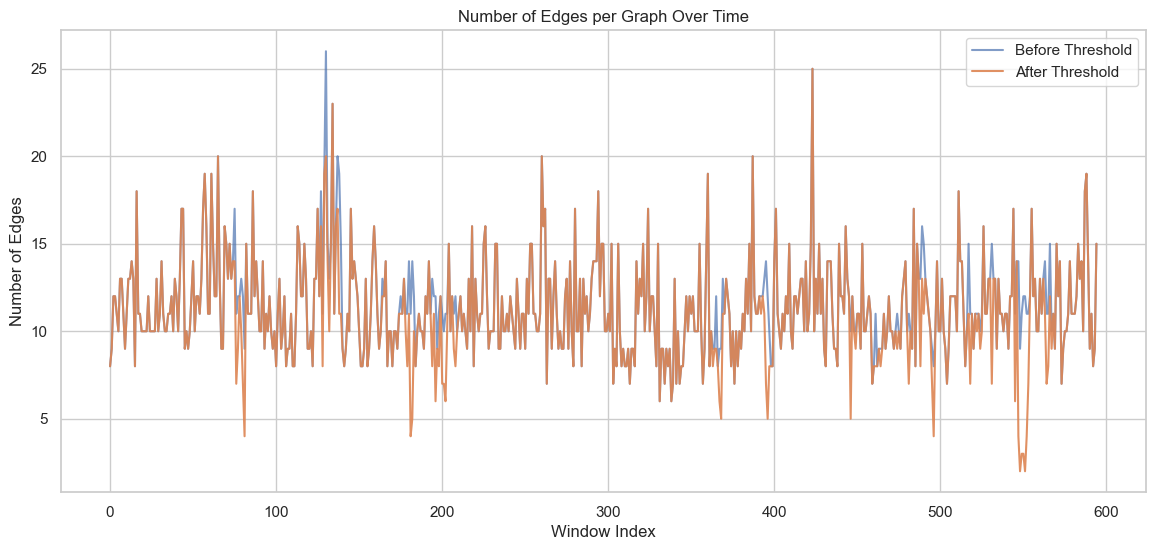

In [10]:
edges_per_graph_before = [g.number_of_edges() for g in graphs]
edges_per_graph_after = [g.number_of_edges() for g in filtered_graphs]

plt.figure(figsize=(14, 6))
plt.plot(edges_per_graph_before, label="Before Threshold", alpha=0.7)
plt.plot(edges_per_graph_after, label="After Threshold", alpha=0.9)
plt.title("Number of Edges per Graph Over Time")
plt.xlabel("Window Index")
plt.ylabel("Number of Edges")
plt.legend()
plt.show()

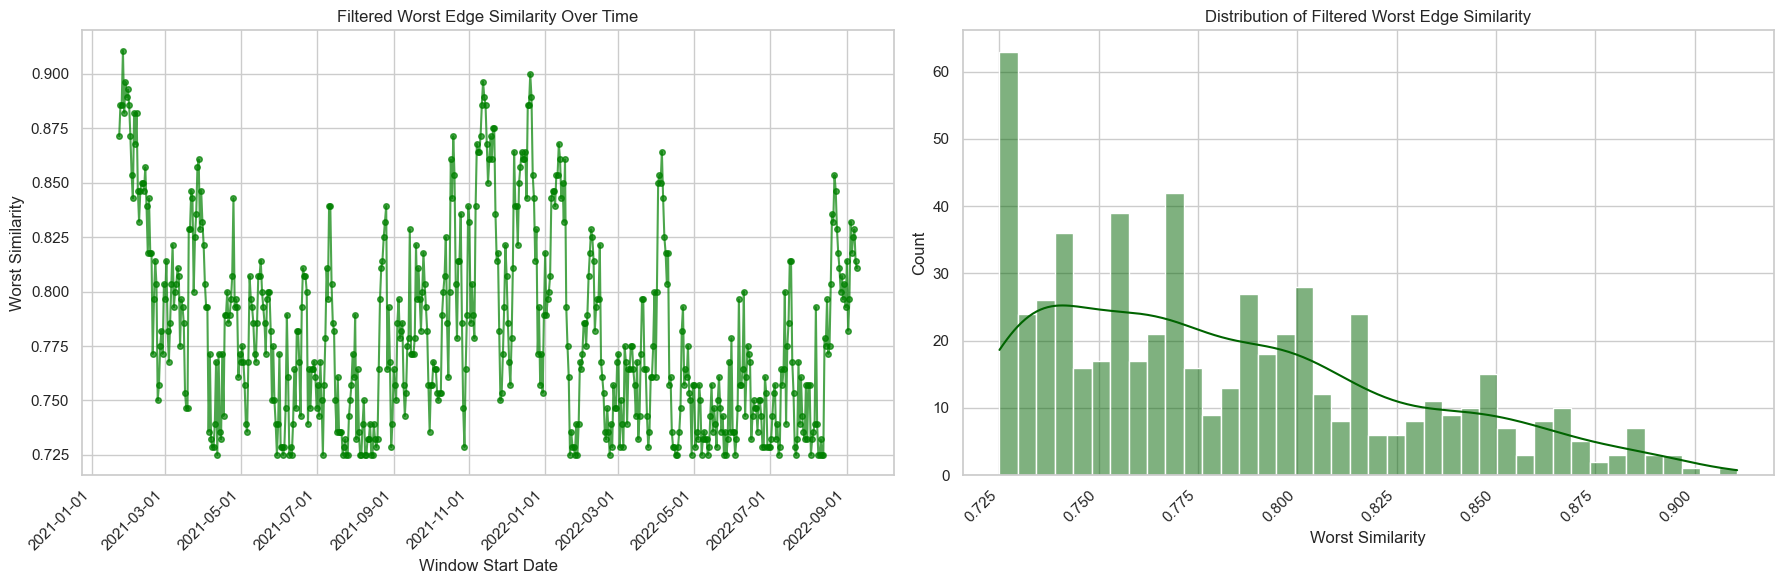

In [11]:
import matplotlib.dates as mdates

# Compute worst distance (or similarity) for each filtered graph
filtered_stats = []
for i, g in enumerate(filtered_graphs):
    weights = [data.get('weight', 0) for u, v, data in g.edges(data=True)]
    start_date = g.graph.get('start_date')
    if len(weights) > 0:
        worst = np.max(weights) if METRIC_TYPE == 'distance' else np.min(weights)
    else:
        worst = np.nan
    filtered_stats.append({'window_start': start_date, 'worst': worst})

df_filtered = pd.DataFrame(filtered_stats)
df_filtered['window_start'] = pd.to_datetime(df_filtered['window_start'])
worst_series_filtered = df_filtered['worst']

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Line plot over time
ax[0].plot(df_filtered['window_start'], worst_series_filtered, marker='o', markersize=4, linestyle='-', alpha=0.7, color='green')
ax[0].set_title(f"Filtered Worst Edge {METRIC_TYPE.capitalize()} Over Time")
ax[0].set_xlabel("Window Start Date")
ax[0].set_ylabel(f"Worst {METRIC_TYPE.capitalize()}")
ax[0].xaxis.set_major_locator(mdates.AutoDateLocator())
ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate(rotation=45)

# Histogram of worst distances
sns.histplot(worst_series_filtered.dropna(), bins=40, kde=True, ax=ax[1], color='darkgreen')
ax[1].set_title(f"Distribution of Filtered Worst Edge {METRIC_TYPE.capitalize()}")
ax[1].set_xlabel(f"Worst {METRIC_TYPE.capitalize()}")

plt.tight_layout()
plt.show()